In [3]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
from cil.optimisation.functions import ZeroFunction, MixedL21Norm, L2NormSquared, BlockFunction
from cil.optimisation.operators import GradientOperator, BlockOperator,IdentityOperator, SymmetrisedGradientOperator, ZeroOperator
from cil.optimisation.algorithms import PDHG
from cil.framework import ImageGeometry
from skimage import data
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity as ssim
from cil.utilities.dataexample import TestData

In [4]:
# Load chelsea image from skimage
image = data.astronaut().astype("float32")/255.0

In [5]:
# Setup the image domain and fill the image into an ImageData
ig = ImageGeometry(voxel_num_y=image.shape[1], voxel_num_x=image.shape[0], channels=image.shape[2],
                  dimension_labels=['horizontal_x', 'horizontal_y', 'channel'])
data = ig.allocate()
data.fill(image)

In [6]:
# Add gaussian noise
n1 = TestData.random_noise(data.as_array(), mode = 'gaussian', seed = 10, var = 0.01)
noisy_data = ig.allocate()
noisy_data.fill(n1)

In [10]:
noisy_data.min()

0.0

In [39]:
# Create operators

tmp_alpha = [0.06]
recons = []
for i in range(len(tmp_alpha)):
    
    alpha = 0.2
    beta = 0.3
    
#     alpha = tmp_alpha[i]
#     beta = alpha 
    

    K11 = GradientOperator(ig)
    K12 = IdentityOperator(K11.range)
    K22 = SymmetrisedGradientOperator(K11.range)    
    K21 = ZeroOperator(ig, K22.range)    

    K = BlockOperator(K11, -K12, K21, K22, shape=(2,2) )      

    f1 = alpha * MixedL21Norm()
    f2 = beta * MixedL21Norm() 
    f3 = 0.5 * L2NormSquared(b=noisy_data)

    F = BlockFunction(f1, f2)         
    G = BlockFunction(f3, ZeroFunction())

    # Compute operator Norm
    normK = K.norm()

    # Primal & dual stepsizes
    sigma = 1./normK
    tau = 1./normK

    # Setup and run the PDHG algorithm
    pdhg = PDHG(f=F,g=G,operator=K, tau=tau, sigma=sigma,
                max_iteration = 2000,
                update_objective_interval = 200)
    pdhg.run(1000, verbose=2)
    recons.append(pdhg.solution.get_item(0))
    
    ssim_noise = ssim(data.as_array(), pdhg.solution.get_item(0).as_array(),
                      data_range=pdhg.solution.get_item(0).max() - pdhg.solution.get_item(0).min(), multichannel=True)    
    print("alpha is {} and ssim is {}".format(alpha, ssim_noise))
    

Initialised GradientOperator with numpy backend
PDHG setting up
PDHG configured
     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0       2000         0.189    1.21858e+05  -0.00000e+00    1.21858e+05
      200       2000         0.180    5.55591e+03   5.28815e+03    2.67757e+02
      400       2000         0.179    5.49236e+03   5.38085e+03    1.11504e+02
      600       2000         0.182    5.47229e+03   5.40585e+03    6.64439e+01
      800       2000         0.182    5.46273e+03   5.41661e+03    4.61259e+01
     1000       2000         0.185    5.45724e+03   5.42235e+03    3.48908e+01
----------------------------------------------------------------------------
     1000       2000         0.185    5.45724e+03   5.42235e+03    3.48908e+01
Stop criterion has been reached.

alpha is 0.2 and ssim is 0.6761959759411683


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


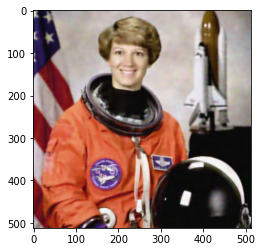

In [38]:
for i in range(1):
    plt.figure()
    plt.imshow(recons[i].as_array())
    plt.show

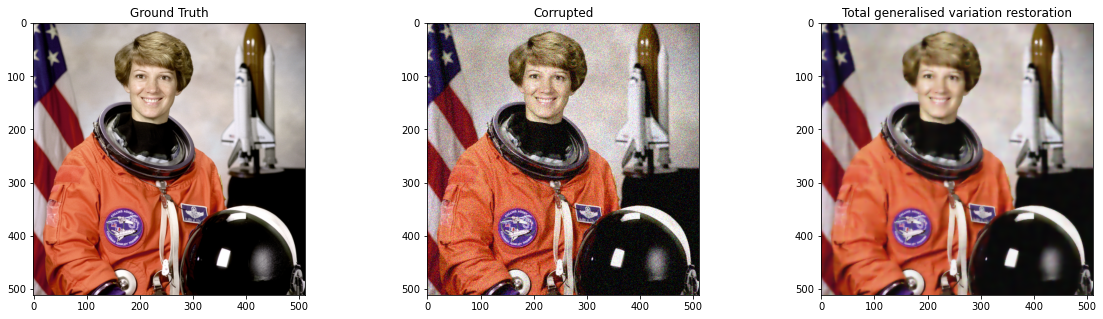

In [19]:
fig = plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.imshow(data.as_array())
plt.title('Ground Truth')
plt.subplot(1, 3, 2)
plt.imshow(noisy_data.as_array())
plt.title('Corrupted')
plt.subplot(1, 3, 3)
plt.imshow(pdhg.solution.get_item(0).as_array())
plt.title('Total generalised variation restoration')
plt.show()